<a href="https://colab.research.google.com/github/NMelbard/PBL1/blob/main/PBL2/reworked_heparin_secretion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simplified the heparin model to simulate constitutive secretion instead. This way, it doesn't need a trigger/signal accounted for. Instead, the molecule is continously synthesized, packaged in the ER, and sent via vesicles to the cell membrane.

\begin{align}
\frac{dH}{dt} &= v_{\text{sulfation}} - v_{\text{packaging}}([H]) - k_{\deg} [H] \\
\\
\frac{dV}{dt} &= \frac{1}{q} \, v_{\text{packaging}}([H]) - k_{\text{sec}} V \\
\\
\frac{dS}{dt} &= q \, k_{\text{sec}} V - k_{\deg} [S]
\end{align}

Concentrations in terms of mM and time in terms of min

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
def v_packaging(H, K, Vmax, n):
  return Vmax * H**n / (K**n + H**n)

In [3]:
def f_hep(t, y, c, k_sulfation):
  '''
  c = [Kpack, Vmax, n, ksec, q, k_deg] # Updated docstring to reflect added k_deg
  '''
  # Unpack state variables: [Heparosan, Heparin, PAPS, Reserve Vesicles, Calcium, Release Vesicles, Secreted Heparin]
  Hs, Hp, PAPS, V, S = y

  # Heparosan to Heparin conversion rate
  v_sulfation = k_sulfation * Hs * PAPS

  # Unpack parameters from c for clarity and correct indexing
  Kpack, Vmax, n, ksec, q, k_deg = c # Unpack k_deg

  #heparosan-heparin equations from Jacob
  dHs_dt = -v_sulfation
  dHp_dt = v_sulfation - v_packaging(Hp, Kpack, Vmax, n) - k_deg * Hp # Changed n1 to n and ksec to k_deg
  dPAPS_dt = -v_sulfation

  #exocytosis
  dV_dt = (1/q) * v_packaging(Hp, Kpack, Vmax, n) - ksec * V
  dS_dt = q * ksec * V - k_deg*S# Changed Ksec to ksec

  return [dHs_dt, dHp_dt, dPAPS_dt, dV_dt, dS_dt]

In [4]:
#parameters (made up, need literature values)
Kpack = 0.1 #affinity constant for packaging heparin, goes in the hill function. (mM)
Vmax = 0.1 #maximum packaging rate coefficient (mM/min)
n = 1 #hill coefficent for heparin packaging
ksec = 0.5 #secretion rate constsant; "removal" of vesicles from ER. (1/min)
q = 1e-3 #amount of heparin molecules per vesicle (mM)
k_sulfation = 0.05 # lumped reaction rate constant for sulfation. (1/(mM*min))
k_deg = 0.01 # degradation rate constant for heparin (1/min)

In [5]:
t_end = 720 # Define t_end for the simulation time

# parameters for f_hep: [Kpack, Vmax, n, ksec, q, k_deg]
c = [Kpack, Vmax, n, ksec, q, k_deg] # Corrected c list to match f_hep expected parameters

# Initial conditions for [Hs, Hp, PAPS, R, C, V, S]
# Using initial conditions from the sulfation model (Hs0, Hp0, PAPS0) and existing exocytosis model
Hs0 = 10.0    # initial heparosan (from sulfation model)
Hp0 = 0.0     # initial heparin (from sulfation model, and H in exocytosis)
PAPS0 = 12.0  # initial PAPS (from sulfation model)
V0 = 0     # initial V (from existing exocytosis model in y_init)
S0 = 0.0      # initial S (from existing exocytosis model in y_init)

y_init = [Hs0, Hp0, PAPS0, V0, S0]

tspan = np.linspace(0, t_end, 1000)
sol = solve_ivp(lambda t, y: f_hep(t, y, c, k_sulfation), [tspan[0], tspan[-1]], y_init, t_eval=tspan)
print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  7.207e-01 ...  7.193e+02  7.200e+02]
        y: [[ 1.000e+01  6.904e+00 ...  9.672e-32  9.000e-32]
            [ 0.000e+00  3.019e+00 ...  2.594e-10  1.265e-10]
            ...
            [ 0.000e+00  5.515e+01 ... -5.085e-07 -2.480e-07]
            [ 0.000e+00  9.947e-03 ...  7.968e-03  7.911e-03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1562
     njev: 0
      nlu: 0


In [6]:
eqs = ["Heparosan", "Heparin", "PAPS", "Vesicles formation", "Exported Heparin"]

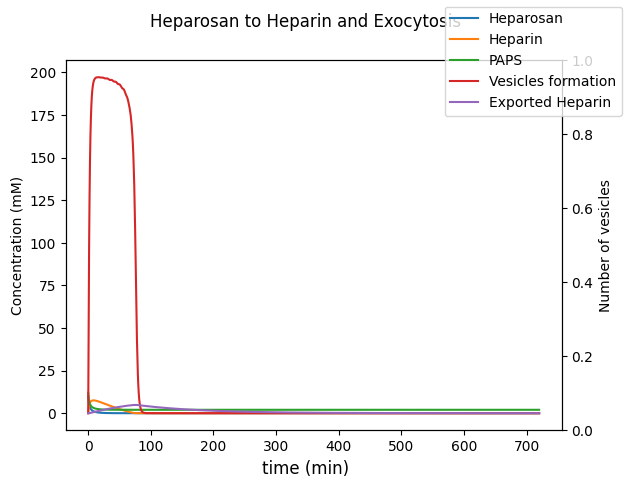

<Figure size 2400x1200 with 0 Axes>

In [7]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

plt.figure(figsize=(8,4),dpi=300)
for i, s in enumerate(sol.y):
  if eqs[i] in ["Reserve Vesicles", "Ready Vesicles"]:
    ax2.plot(sol.t, s, label=eqs[i])
  else:
    ax1.plot(sol.t, s, label=eqs[i])

fig.supxlabel('time (min)')
ax1.set_ylabel('Concentration (mM)')
ax2.set_ylabel('Number of vesicles')
fig.legend()
fig.suptitle('Heparosan to Heparin and Exocytosis')
plt.show()

Text(0.5, 1.0, 'Vesicles formation')

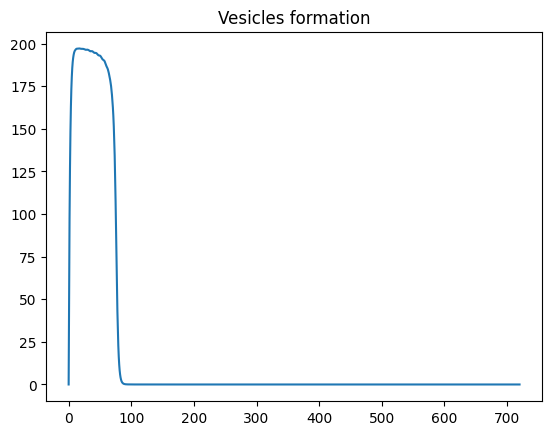

In [8]:
i = 3
plt.plot(sol.t, sol.y[i])
plt.title(eqs[i])